![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Agnostic Interpretation with LIME

In this Notebook, we will demonstrate how to use the Local Interpretable Model-Agnostic Explanations (LIME) method ([Rubiero et. al., 2016](https://doi.org/10.1145/2939672.2939778)) and interpret its results.

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-random-forest/Gen-2-Tutorial_LIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also have received an email that informs you about the access on your Google Drive.

In [1]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [2]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [3]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-random-forest.txt
# %cd xai-for-random-forest

### Imports

Let's start with importing all required Python packages.

In [4]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler

from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LinearRegression # used as surrogate model for LIME

import warnings
warnings.filterwarnings('ignore')

Now, we fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [5]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

--------

## Data and Model Loading: The Wisconsin Breast Cancer Dataset

In this notebook, we will work with the **Wisconsin Breast Cancer dataset**, containing 569 samples of 212 malignant and 357 benign tumors. Tumors are described by 30 numeric features computed from a digitized image taken of breast mass (for more details please see descrption [here](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset)).

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_breastcancer.png?raw=true" width="700" /></center>

<font size=1> Source: [Link](https://www.kaggle.com/code/midouazerty/breast-cancer-prediction-99)

In the notebook [*Bio-0-Tutorial_RandomForest_Model_BreastCancer.ipynb*](./Bio-0-Tutorial_RandomForest_Model_BreastCancer.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook is the interpretation of the previously trained model.

In [6]:
# Load and unpack the data
with open('../models/model_rf_breastcancer.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)

X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_breastcancer = data_and_model[4]

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(balanced_accuracy_score(y_train, model_breastcancer.predict(X_train))*100,2)} % balanced accuracy.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(balanced_accuracy_score(y_test, model_breastcancer.predict(X_test))*100,2)} % balanced accuracy.')

Model Performance on training data: 100.0 % balanced accuracy.
Model Performance on test data: 94.05 % balanced accuracy.


As we can see by the numbers above, our model performs well on the training set and also generalizes well to the independent test set.

**You should keep in mind that interpreting a low-performing model can lead to wrong conclusions.**

--------

## Now, what does my model think is important in the data?

### Local Interpretable Model-Agnostic Explanations (LIME)

**We prepared a small [Introduction to LIME](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html) for you, to help you understand how this method works.**

*Note: we provide all references [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html#references).*

<font color='green'>

#### Question 1: What is a surrogate model?

<font color='grey'>

#### Your Answer: 
It’s an interpretable model, such as linear or tree models, that approximates the prediction of a more complex model.


<font color='green'>

#### Question 2: How is LIME using surrogate models to explain a model prediction?

<font color='grey'>

#### Your Answer: 
It randomly samples data points in the neighbourhood of the sample point and lets the complex model make predictions for those points. This data set is then used to fit a surrogate model which can than be analysed to identify important features.

Now we use LIME to gain insights into the trained Random Forest classification model.  

A key parameter in LIME is the *kernel_width*, which controls how strongly perturbed samples are weighted based on their distance to the instance being explained. Smaller values enforce a more local explanation by giving higher weight to very similar samples, while larger values result in a broader, more global approximation. Choosing an appropriate kernel width is challenging and remains an open research question. It is also one of the main limitations of LIME, as explanations can vary substantially depending on this parameter. Feel free to experiment with different values and observe how the explanations change.

*Note: this method is a local method, which means that it only provides explanations for individual samples but not for a full dataset.*

In [7]:
kernel_width = 1 # default is 0.75 * sqrt(n_features)

Before applying LIME, we standardize the input features using a `StandardScaler`. Although the Random Forest model itself does not require scaling, LIME relies on distance-based sampling and weighting when generating local perturbations. Since Euclidean distance is sensitive to feature scale, unscaled features with larger numeric ranges could dominate the locality definition and distort the explanation.

After scaling, we initialize the `LimeTabularExplainer`, which uses the scaled training data as the background distribution for generating local perturbations around the instance being explained.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data=X_train_scaled,  # Background data used to generate perturbed samples
    mode="classification",  # Specifies task type ("classification" or "regression")
    training_labels=y_train,  # True labels used for class handling
    feature_names=X_train.columns,  # Feature names shown in explanations
    feature_selection='none',  # Strategy for selecting features in the surrogate model
    random_state=seed,  # Ensures reproducibility of sampling
    sample_around_instance=True,  # Generate perturbations around the instance itself instead of global mean (default)
    kernel_width=kernel_width,  # Controls locality weighting in the surrogate model
    discretize_continuous=False  # Whether to discretize continuous features before explanation
)

Once we have defined the setup for LIME, we select an instance of interest for which we want to generate explanations, define the neighborhood size (i.e., the number of perturbed samples used to fit the surrogate model), and choose the type of surrogate model. The neighborhood size should be sufficiently large to ensure that the surrogate model is trained on enough locally perturbed samples. As a surrogate model, we use **Linear Regression**, since its coefficients provide an intrinsically interpretable representation of feature influence in the local region around the instance.

When using LIME, both the prediction function and the explanation target depend on the learning task:

- For **regression**, we pass the model’s `predict` function, since LIME explains the predicted continuous output directly. No class selection is required because there is only a single numeric prediction.

- For **classification**, we pass the model’s `predict_proba` function, as LIME requires class probability scores rather than discrete class labels. In addition, we must specify which class to explain:
  - `top_labels=1` explains the **predicted class** (recommended for understanding the model’s decision).
  - `labels=(instance_label,)` explains the **true class** (useful when analyzing misclassifications).

Because we standardized the data before passing it to LIME, the perturbed samples generated by the explainer are also in standardized space. However, the Random Forest model was trained on the original (unscaled) feature values. Therefore, we use `scaler.inverse_transform` inside the `predict_proba` function to transform the perturbed samples back to the original feature scale before passing them to the model. This ensures that predictions are computed in the correct feature space and remain consistent with the trained model.

In [9]:
# choose an instance that you want to explain
inst_idx = 94 # Index of the sample to explain
instance = X_train_scaled[inst_idx]  # Feature vector of the selected instance
print(f"Instance {inst_idx} of training data will be explained. The true class is {y_train.iloc[inst_idx]} and the predicted class for this instance is: {model_breastcancer.predict(scaler.inverse_transform(instance.reshape(1, -1)))[0]}.")

# number of samples in the neighborhood used to fit the local surrogate model
num_samples = 5000  # Size of perturbed neighborhood generated around the instance

explanation = explainer.explain_instance(
    data_row=instance,  # The instance for which we want an explanation
    predict_fn=lambda x: model_breastcancer.predict_proba(scaler.inverse_transform(x)),  # Function returning class probabilities
    top_labels=1,  # Explain the class with the highest predicted probability
    model_regressor=LinearRegression(),  # Local surrogate model approximating the RF
    num_samples=num_samples,  # Number of perturbed samples used to fit the surrogate
)

Instance 94 of training data will be explained. The true class is 1_Cancer and the predicted class for this instance is: 1_Cancer.


To assess how well the simpler surrogate model approximates the predictions of the complex model, we need a metric that summarizes the quality of the surrogate’s predictions. This metric serves as a **fidelity measure**, indicating how reliably the interpretable model represents the behavior of the original model in the local neighborhood.

While the choice of fidelity metric is flexible, it is essential to evaluate the surrogate model’s predictive performance whenever LIME explanations are used. After all, how much confidence would you place in an explanation generated by a surrogate model that fails to approximate the complex model’s predictions accurately?

In our case, we use a linear regression model as the surrogate. A commonly used measure of goodness of fit for linear regression is the $R^2$ score. It quantifies how well the linear model explains the variation in the complex model’s predictions within the local neighborhood. An $R^2$ value close to 1 indicates a strong local approximation, whereas lower values suggest that the surrogate model may not faithfully capture the complex model’s behavior.

In [10]:
print(f"Score of the local surrogate model: {round(explanation.score, 4)}.")

Score of the local surrogate model: 0.5017.


All that LIME did was to fit a linear regression model to approximate the complex model's predictions, i.e., the predictions of the Random Forest model. The dataset for creating the fit consists of the neighborhood samples that were randomly created around our selected instance. 

Linear regression models estimate a single parameter (coefficient) for each feature. Those coefficients describe the mathematical relationship between each feature (independent variable) and the target (dependent variable). The sign of a linear regression coefficient tells you whether there is a positive or negative correlation between the feature and the target. The coefficient value signifies how much the mean of the target changes given a one-unit shift in the feature while holding other features in the model constant. Hence, we can plot the coefficients of the Linear Regression Surrogate model to understand which features are most predictive for our instance of interest.

*Note: LIME is not restricted to linear regression models; other easy-to-interpret surrogate models could be used like decision trees.*

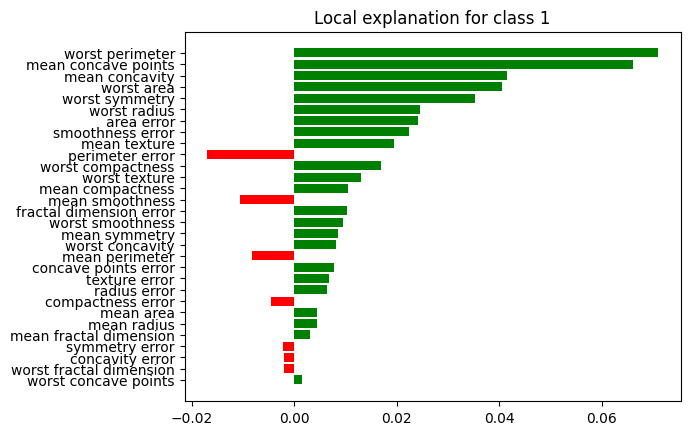

In [11]:
explanation.as_pyplot_figure(); # semicolon added because as_pyplot_figure displays and returns the figure, which in turn gets displayed by jupyter if you don't assign it to anything.

For this example, we an instance where the true class is **1_Cancer**, and the Random Forest model also predicts **1_Cancer**, indicating a correct classification.

The local explanation for class 1 highlights the features that most strongly influenced the model’s decision for this specific patient. Features shown in **green** push the prediction toward class 1 (malignant), while features shown in **red** push it away from class 1 (toward the benign class). The length of each bar represents the weight assigned by the local linear surrogate model. Larger absolute values indicate stronger influence within the local neighborhood around this instance.

The strongest positive contributors include *worst perimeter*, *mean concave points*, *mean concavity*, and *worst area*. For this instance, elevated values of these features substantially increase the predicted probability of malignancy, according to the surrogate model.

Importantly, this explanation is **local**: it describes how the model arrived at its prediction for this particular sample and does not necessarily reflect global feature importance across the dataset.

<font color='green'>

#### Question 3: What are the main differences to Permutation Feature Importance?

<font color='grey'>

#### Your Answer: 
LIME is purely local and can only explain one instance at a time.